Libraries loaded successfully.
IPI raw shape: (10348, 4)
Electricity raw shape: (468, 3)

===== 2. DATA PREPARATION =====
IPI absolute series shape: (3562, 4)
IPI missing values:
 series      0
date        0
division    0
index       0
dtype: int64
IPI duplicate rows: 0
Manufacturing IPI (average) shape: (137, 2)

Electricity sectors:
 sector
total               78
local               78
local_commercial    78
local_domestic      78
exports             78
losses              78
Name: count, dtype: int64
Electricity missing values:
 date           0
sector         0
consumption    0
dtype: int64
Commercial electricity shape: (78, 2)

===== COMBINED DATASET =====
Combined shape (2018–mid-2024): (78, 3)
        date     mfg_ipi  elec_commercial_mkwh
0 2018-01-01  114.021167           9390.080801
1 2018-02-01  106.709875           8561.415143
2 2018-03-01  115.275458           9659.320215
3 2018-04-01  113.033708           9340.784017
4 2018-05-01  116.392542           9525.937602
5 2018-0

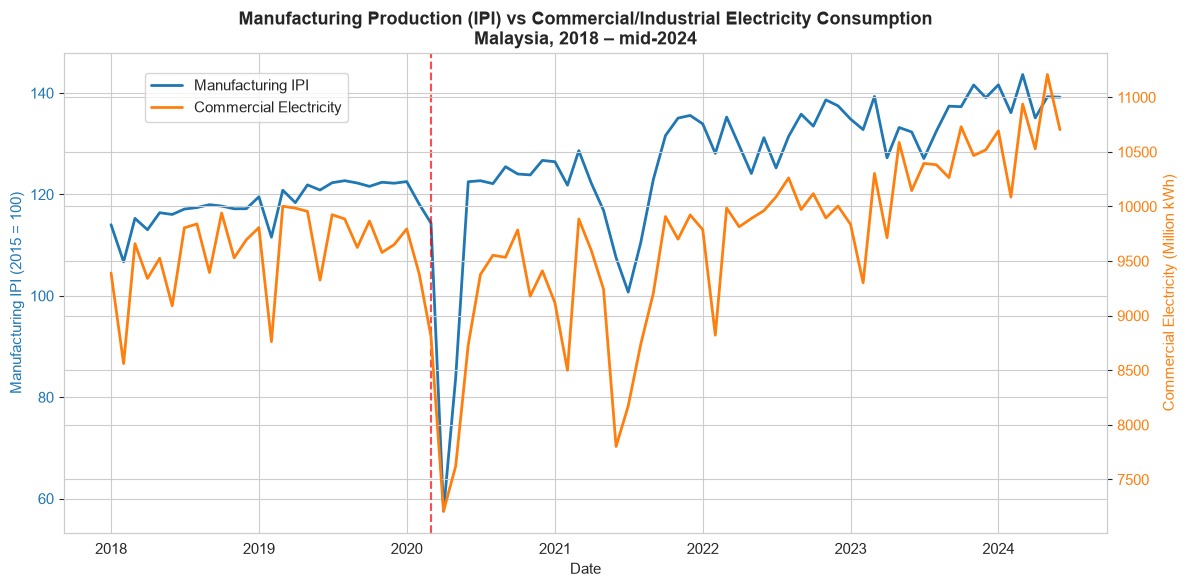

Saved: viz1_ipi_vs_electricity_timeseries.png


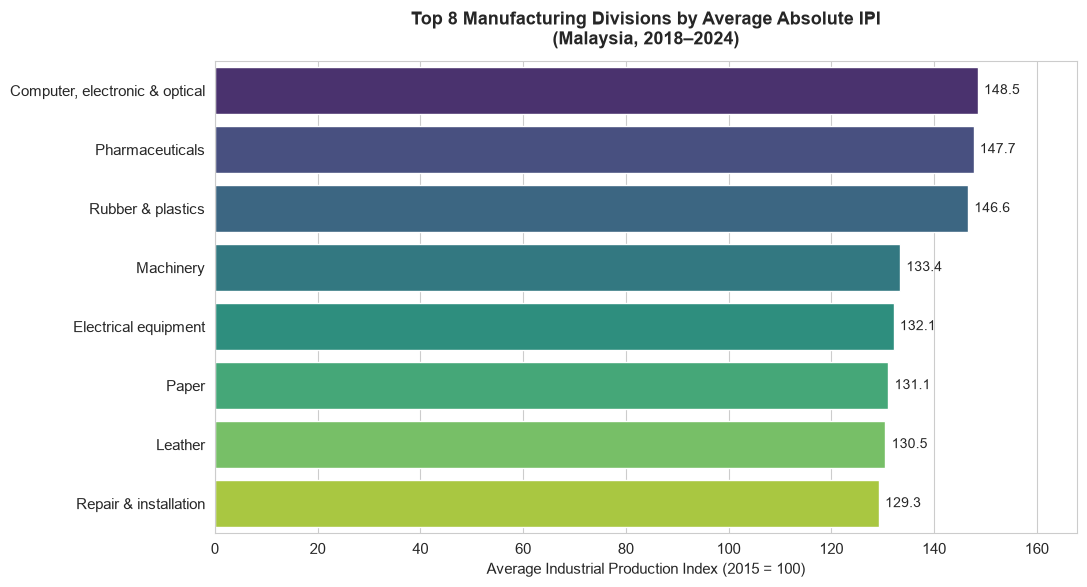

Saved: viz2_top_divisions_ipi.png


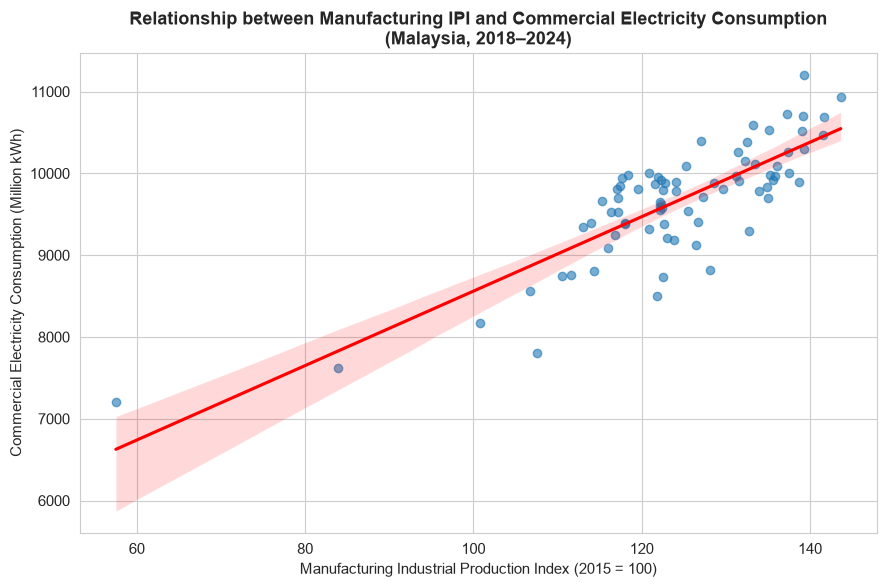

Saved: viz3


In [6]:
# ============================================================
# BTPR3203 PYTHON FOR DATA SCIENCE
# CASE STUDY: Sustainable Manufacturing & Industrial Automation in Malaysia
# Combined Datasets: DOSM IPI (2-digit) + Electricity Consumption
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("Libraries loaded successfully.")

# ------------------------------------------------------------
# 1. Load Datasets
# ------------------------------------------------------------
ipi = pd.read_csv("ipi_2d_malaysia.csv", parse_dates=["date"])
print("IPI raw shape:", ipi.shape)

elec = pd.read_csv("electricity_consumption.csv", parse_dates=["date"])
print("Electricity raw shape:", elec.shape)

# ------------------------------------------------------------
# 2. Data Preparation (addresses Research Question 1)
# ------------------------------------------------------------
print("\n===== 2. DATA PREPARATION =====")

# Keep only absolute index series
ipi_abs = ipi[ipi["series"] == "abs"].copy()

# IMPORTANT FIX: force division to 2-digit string
ipi_abs["division"] = ipi_abs["division"].astype(str).str.zfill(2)

print("IPI absolute series shape:", ipi_abs.shape)
print("IPI missing values:\n", ipi_abs.isnull().sum())
print("IPI duplicate rows:", ipi_abs.duplicated().sum())

ipi_abs["year"] = ipi_abs["date"].dt.year
ipi_abs["month"] = ipi_abs["date"].dt.month

msic_labels = {
    "06": "Mining of oil & gas",
    "10": "Food products",
    "11": "Beverages",
    "12": "Tobacco",
    "13": "Textiles",
    "14": "Wearing apparel",
    "15": "Leather",
    "16": "Wood",
    "17": "Paper",
    "18": "Printing",
    "19": "Coke & refined petroleum",
    "20": "Chemicals",
    "21": "Pharmaceuticals",
    "22": "Rubber & plastics",
    "23": "Non-metallic mineral",
    "24": "Basic metals",
    "25": "Fabricated metal",
    "26": "Computer, electronic & optical",
    "27": "Electrical equipment",
    "28": "Machinery",
    "29": "Motor vehicles",
    "30": "Other transport",
    "31": "Furniture",
    "32": "Other manufacturing",
    "33": "Repair & installation",
    "35": "Electricity"
}
ipi_abs["division_name"] = ipi_abs["division"].map(msic_labels).fillna(ipi_abs["division"])

mfg_divs = [d for d in ipi_abs["division"].unique() if d not in ["06", "35"]]
mfg_ipi = (ipi_abs[ipi_abs["division"].isin(mfg_divs)]
           .groupby("date")["index"]
           .mean()
           .reset_index()
           .rename(columns={"index": "mfg_ipi"}))

print("Manufacturing IPI (average) shape:", mfg_ipi.shape)

print("\nElectricity sectors:\n", elec["sector"].value_counts())
print("Electricity missing values:\n", elec.isnull().sum())

elec_comm = elec[elec["sector"] == "local_commercial"][["date", "consumption"]].copy()
elec_comm = elec_comm.rename(columns={"consumption": "elec_commercial_mkwh"})
print("Commercial electricity shape:", elec_comm.shape)

combined = pd.merge(mfg_ipi, elec_comm, on="date", how="inner")
combined = combined.sort_values("date").reset_index(drop=True)

print("\n===== COMBINED DATASET =====")
print("Combined shape (2018–mid-2024):", combined.shape)
print(combined.head(10))
print("\nDescriptive statistics:")
print(combined.describe())

combined.to_csv("combined_mfg_ipi_electricity.csv", index=False)
print("\nCombined dataset saved as 'combined_mfg_ipi_electricity.csv'")

# ------------------------------------------------------------
# 3. Analysis (addresses Research Question 2)
# ------------------------------------------------------------
print("\n===== 3. ANALYSIS =====")

ipi_period = ipi_abs[(ipi_abs["date"] >= "2018-01-01") & (ipi_abs["date"] <= "2024-06-01")]
div_rank = (ipi_period.groupby(["division", "division_name"])["index"]
            .mean()
            .sort_values(ascending=False)
            .reset_index())

print("\n--- Top 8 Manufacturing Divisions by Average Absolute IPI (2018–2024) ---")
print(div_rank.head(8)[["division", "division_name", "index"]].to_string(index=False))

def calc_cagr(start, end, years):
    return (end / start) ** (1 / years) - 1

selected_divs = ["26", "27", "21", "20", "22", "10"]
cagr_list = []

for div in selected_divs:
    s = ipi_period[ipi_period["division"] == div].set_index("date")["index"].sort_index()
    if len(s) > 12:
        start_val = s.iloc[0]
        end_val = s.iloc[-1]
        years = (s.index[-1] - s.index[0]).days / 365.25
        cagr_list.append({
            "division": div,
            "division_name": msic_labels.get(div, div),
            "start_ipi": round(start_val, 1),
            "end_ipi": round(end_val, 1),
            "cagr_pct": round(calc_cagr(start_val, end_val, years) * 100, 2)
        })

cagr_df = pd.DataFrame(cagr_list).sort_values("cagr_pct", ascending=False)
print("\n--- CAGR of Selected Divisions (2018–2024) ---")
print(cagr_df.to_string(index=False))

corr, p_value = stats.pearsonr(combined["mfg_ipi"], combined["elec_commercial_mkwh"])
print("\n--- Correlation: Manufacturing IPI vs Commercial Electricity ---")
print(f"Pearson correlation coefficient: {corr:.4f}")
print(f"p-value: {p_value:.4e}")
if p_value < 0.05:
    print("Result: Statistically significant positive relationship.")
else:
    print("Result: Not statistically significant.")

# ------------------------------------------------------------
# 4. Visualisations (addresses Research Question 3)
# ------------------------------------------------------------
print("\n===== 4. VISUALISATIONS =====")

fig, ax1 = plt.subplots(figsize=(12, 6))

color1 = "tab:blue"
ax1.set_xlabel("Date")
ax1.set_ylabel("Manufacturing IPI (2015 = 100)", color=color1)
ax1.plot(combined["date"], combined["mfg_ipi"], color=color1, linewidth=2, label="Manufacturing IPI")
ax1.tick_params(axis="y", labelcolor=color1)
ax1.axvline(pd.Timestamp("2020-03-01"), color="red", linestyle="--", alpha=0.7)

ax2 = ax1.twinx()
color2 = "tab:orange"
ax2.set_ylabel("Commercial Electricity (Million kWh)", color=color2)
ax2.plot(combined["date"], combined["elec_commercial_mkwh"], color=color2, linewidth=2, label="Commercial Electricity")
ax2.tick_params(axis="y", labelcolor=color2)

plt.title("Manufacturing Production (IPI) vs Commercial/Industrial Electricity Consumption\nMalaysia, 2018 – mid-2024",
          fontsize=13, fontweight="bold")
fig.tight_layout()
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.88))
plt.savefig("viz1_ipi_vs_electricity_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: viz1_ipi_vs_electricity_timeseries.png")

top8 = div_rank.head(8).copy()

plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=top8,
    y="division_name",
    x="index",
    palette="viridis",
    orient="h"
)

plt.title("Top 8 Manufacturing Divisions by Average Absolute IPI\n(Malaysia, 2018–2024)",
          fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Average Industrial Production Index (2015 = 100)")
plt.ylabel("")

for i, (_, row) in enumerate(top8.iterrows()):
    ax.text(row["index"] + 1.2, i, f"{row['index']:.1f}", va="center", fontsize=10)

plt.xlim(0, top8["index"].max() * 1.13)
plt.tight_layout()
plt.savefig("viz2_top_divisions_ipi.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: viz2_top_divisions_ipi.png")

plt.figure(figsize=(9, 6))
sns.regplot(
    data=combined,
    x="mfg_ipi",
    y="elec_commercial_mkwh",
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"}
)
plt.title("Relationship between Manufacturing IPI and Commercial Electricity Consumption\n(Malaysia, 2018–2024)",
          fontsize=13, fontweight="bold")
plt.xlabel("Manufacturing Industrial Production Index (2015 = 100)")
plt.ylabel("Commercial Electricity Consumption (Million kWh)")
plt.tight_layout()
plt.savefig("viz3_scatter_ipi_electricity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: viz3")